In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load the Dataset

In [8]:
df = pd.read_csv("TravelInsurancePrediction.csv")

df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           1987 non-null   int64 
 1   Age                  1987 non-null   int64 
 2   Employment Type      1987 non-null   object
 3   GraduateOrNot        1987 non-null   object
 4   AnnualIncome         1987 non-null   int64 
 5   FamilyMembers        1987 non-null   int64 
 6   ChronicDiseases      1987 non-null   int64 
 7   FrequentFlyer        1987 non-null   object
 8   EverTravelledAbroad  1987 non-null   object
 9   TravelInsurance      1987 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 155.4+ KB


In [10]:
df.shape

(1987, 10)

In [11]:
df.describe()

,Unnamed: 0,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance
count,1987.000000,1987.000000,1.987000e+03,1987.000000,1987.000000,1987.000000
mean,993.000000,29.650226,9.327630e+05,4.752894,0.277806,0.357323
std,573.741812,2.913308,3.768557e+05,1.609650,0.448030,0.479332
min,0.000000,25.000000,3.000000e+05,2.000000,0.000000,0.000000
25%,496.500000,28.000000,6.000000e+05,4.000000,0.000000,0.000000
50%,993.000000,29.000000,9.000000e+05,5.000000,0.000000,0.000000
75%,1489.500000,32.000000,1.250000e+06,6.000000,1.000000,1.000000
max,1986.000000,35.000000,1.800000e+06,9.000000,1.000000,1.000000


# Data Cleaning

In [12]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [13]:
df.isnull().sum()

Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64

In [16]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in Age:
[31 34 28 25 33 26 32 29 35 30 27]

Unique values in Employment Type:
['Government Sector' 'Private Sector/Self Employed']

Unique values in GraduateOrNot:
['Yes' 'No']

Unique values in AnnualIncome:
[ 400000 1250000  500000  700000 1150000 1300000 1350000 1450000  800000
 1400000  850000 1500000 1050000  350000 1100000  600000  900000  550000
  300000  750000 1200000 1000000  950000 1700000 1750000  650000  450000
 1650000 1800000 1550000]

Unique values in FamilyMembers:
[6 7 4 3 8 9 5 2]

Unique values in ChronicDiseases:
[1 0]

Unique values in FrequentFlyer:
['No' 'Yes']

Unique values in EverTravelledAbroad:
['No' 'Yes']

Unique values in TravelInsurance:
[0 1]



# Exploratory Data Analysis

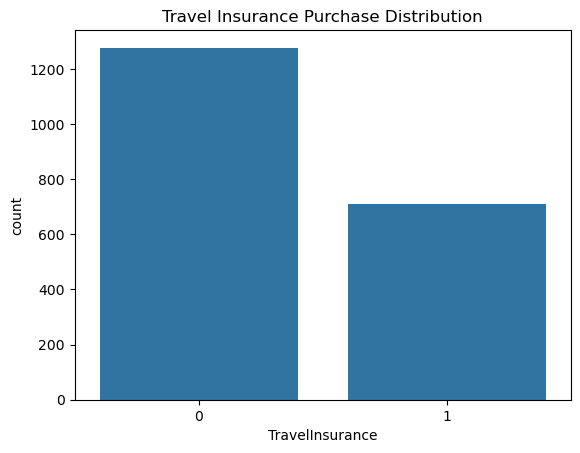

In [17]:
sns.countplot(x="TravelInsurance", data=df)
plt.title("Travel Insurance Purchase Distribution")
plt.show()

In [40]:
class_counts = df['TravelInsurance'].value_counts()
class_percentages = df['TravelInsurance'].value_counts(normalize=True) * 100

# Combine into a readable table
balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

print(balance_df)

                 Count  Percentage (%)
TravelInsurance                       
0                 1277        64.26774
1                  710        35.73226


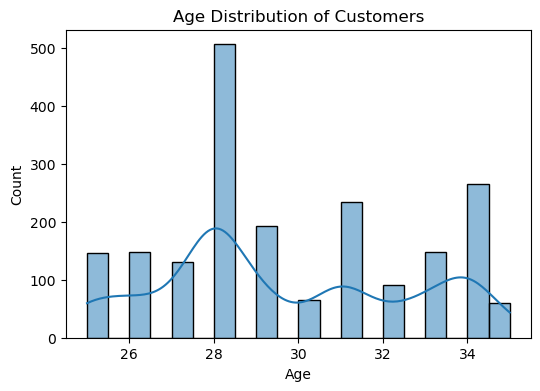

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.show()

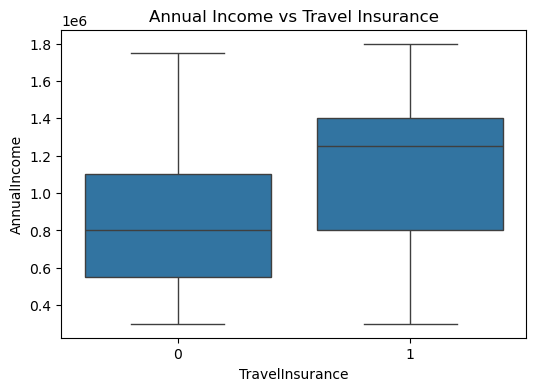

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x="TravelInsurance", y="AnnualIncome", data=df)

plt.title("Annual Income vs Travel Insurance")
plt.show()

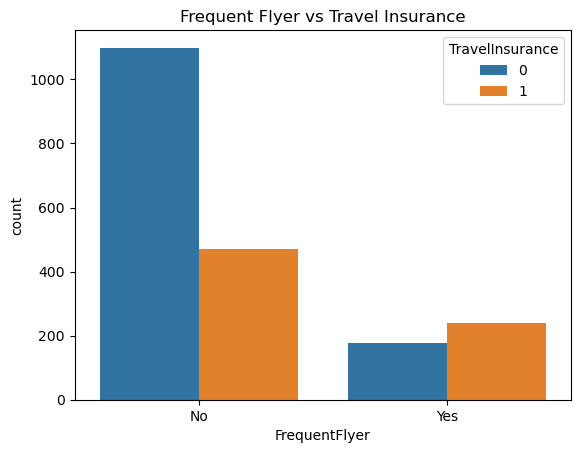

In [20]:
sns.countplot(x="FrequentFlyer", hue="TravelInsurance", data=df)

plt.title("Frequent Flyer vs Travel Insurance")
plt.show()

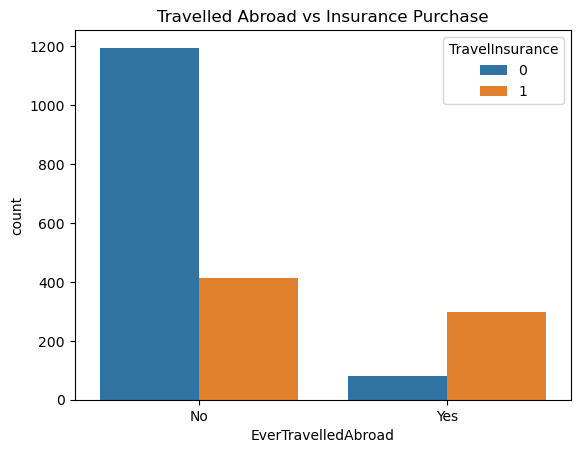

In [21]:
sns.countplot(x="EverTravelledAbroad", hue="TravelInsurance", data=df)

plt.title("Travelled Abroad vs Insurance Purchase")
plt.show()

In [23]:
le = LabelEncoder()

df["Employment Type"] = le.fit_transform(df["Employment Type"])
df["GraduateOrNot"] = le.fit_transform(df["GraduateOrNot"])
df["FrequentFlyer"] = le.fit_transform(df["FrequentFlyer"])
df["EverTravelledAbroad"] = le.fit_transform(df["EverTravelledAbroad"])

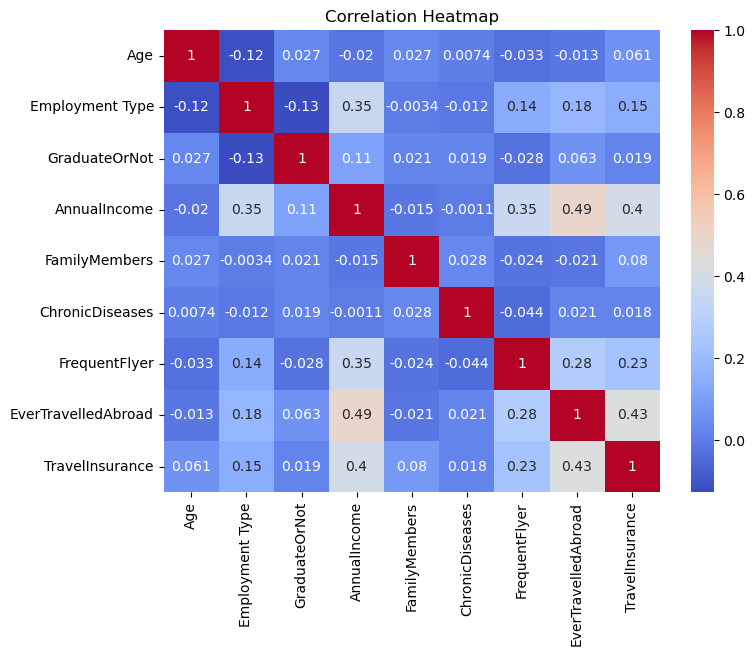

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [25]:
X = df.drop("TravelInsurance", axis=1)
y = df["TravelInsurance"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [51]:
y_pred_log = model.predict(X_test)

In [52]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7688442211055276


In [53]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

In [54]:
y_pred = rf.predict(X_test)

In [55]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8190954773869347


In [56]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       257
           1       0.80      0.65      0.72       141

    accuracy                           0.82       398
   macro avg       0.81      0.78      0.79       398
weighted avg       0.82      0.82      0.81       398



In [57]:
print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))


Confusion Matrix:

[[234  23]
 [ 49  92]]


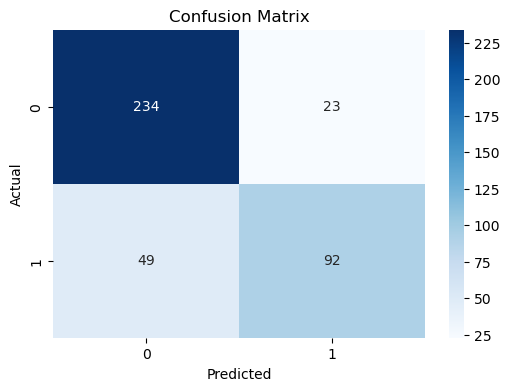

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

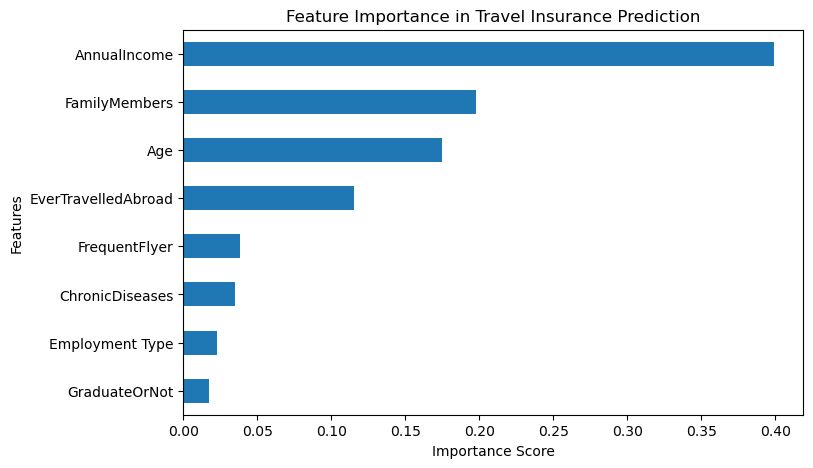

In [59]:
importance = rf.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance in Travel Insurance Prediction")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [61]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7939698492462312


In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediction
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7939698492462312

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       257
           1       0.74      0.64      0.69       141

    accuracy                           0.79       398
   macro avg       0.78      0.76      0.77       398
weighted avg       0.79      0.79      0.79       398


Confusion Matrix:

[[226  31]
 [ 51  90]]


In [65]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8442211055276382

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.89       257
           1       0.99      0.57      0.72       141

    accuracy                           0.84       398
   macro avg       0.90      0.78      0.81       398
weighted avg       0.87      0.84      0.83       398



In [69]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 1.8/101.7 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 2.6/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.4/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 4.5/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 5.2/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.1 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.2/101.7 MB 4.0 MB/s eta 0:00:23
   --- ------------------------------------ 10.0/101.7 MB 4.0 MB/s eta

In [74]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xg = xgb.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print(classification_report(y_test, y_pred_xg))

Accuracy: 0.8391959798994975
              precision    recall  f1-score   support

           0       0.81      0.97      0.89       257
           1       0.92      0.60      0.72       141

    accuracy                           0.84       398
   macro avg       0.87      0.78      0.81       398
weighted avg       0.85      0.84      0.83       398



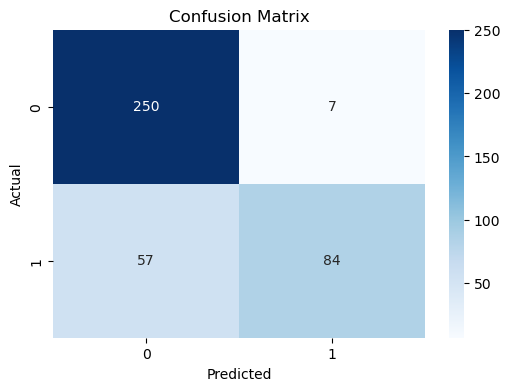

In [78]:
cm = confusion_matrix(y_test, y_pred_xg)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [79]:
importance = xgb.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values(ascending=False)

AnnualIncome           0.358332
FamilyMembers          0.166664
Age                    0.121747
FrequentFlyer          0.075175
ChronicDiseases        0.074397
GraduateOrNot          0.074054
EverTravelledAbroad    0.072321
Employment Type        0.057309
dtype: float32

In [80]:
top_features = features.sort_values(ascending=False).head(5).index

print(top_features)

Index(['AnnualIncome', 'FamilyMembers', 'Age', 'FrequentFlyer',
       'ChronicDiseases'],
      dtype='object')


In [81]:
X_selected = df[top_features]
y = df["TravelInsurance"]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [83]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8391959798994975

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.97      0.89       257
           1       0.92      0.60      0.72       141

    accuracy                           0.84       398
   macro avg       0.87      0.78      0.81       398
weighted avg       0.85      0.84      0.83       398


Confusion Matrix:

[[250   7]
 [ 57  84]]
